### Raw-location duplicate check (pre-registration)
This reports exact duplicate electrode coordinates from raw `*_xslocs.mat` files before MNI registration.


In [1]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat

raw_locs_dir = Path('/Users/rustin/Documents/Big Data 567/faces_basic/locs')
raw_loc_files = sorted(raw_locs_dir.glob('*_xslocs.mat'))

raw_rows = []
row_meta = []
for mat_path in raw_loc_files:
    pid = mat_path.stem.split('_')[0]
    locs = np.asarray(loadmat(mat_path, squeeze_me=True)['locs'], dtype=np.float32).reshape(-1, 3)
    for li, coord in enumerate(locs):
        raw_rows.append(coord)
        row_meta.append((pid, li))

if len(raw_rows) == 0:
    raise FileNotFoundError(f'No raw loc files found in {raw_locs_dir}')

raw_stack = np.vstack(raw_rows)
unique_coords, inverse_idx, counts = np.unique(
    raw_stack, axis=0, return_inverse=True, return_counts=True
)
dup_unique_ids = np.where(counts > 1)[0]

print(f'Raw rows total: {raw_stack.shape[0]}')
print(f'Unique coordinates total: {unique_coords.shape[0]}')
print(f'Unique coordinates with duplicates: {dup_unique_ids.size}')
print()

for g, uid in enumerate(dup_unique_ids, start=1):
    rows = np.where(inverse_idx == uid)[0]
    coord = unique_coords[uid]
    labels = [f"{row_meta[r][0]}[{row_meta[r][1]}]" for r in rows]

    print(f'Group {g}: coord={coord.tolist()} occurs {len(rows)} times')
    print(f'  raw_rows={rows.tolist()}')
    print(f'  subject_local_indices={labels}')
    print()


Raw rows total: 714
Unique coordinates total: 570
Unique coordinates with duplicates: 3

Group 1: coord=[0.0, 0.0, 0.0] occurs 143 times
  raw_rows=[178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 439, 440, 441, 442, 443, 444, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534]
  subject_local_indices=['fp[10]', 'fp[11]', 'fp[12]', 'fp[13]', 'fp[14]', 'fp[15]', 'fp[16]', 'fp[17]', 'fp[18]', 'fp[19]', 'fp[20]', '

### Clean registered locations (remove `[0, 0, 0]` + exact duplicates)
We remove placeholder zero coordinates and exact duplicate rows per subject, then save cleaned files to `registered_outputs_no_duplicates`.
We also create a pooled cleaned file: `all_electrodes_mni_locs_no_dups.npy`.


In [2]:
from pathlib import Path
import numpy as np
project_root = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project')
registered_in_dir = project_root / 'registered_outputs'
registered_out_dir = project_root / 'registered_outputs_no_duplicates'
registered_out_dir.mkdir(parents=True, exist_ok=True)
cleaned_subject_arrays = []
for src_path in sorted(registered_in_dir.glob('*_xslocs_registered_no_dups.npy')):
    pid = src_path.stem.split('_')[0]
    locs = np.asarray(np.load(src_path), dtype=np.float32).reshape(-1, 3)
    zero_mask = np.all(np.isclose(locs, 0.0), axis=1)
    locs_nonzero = locs[~zero_mask]
    nonzero_idx = np.where(~zero_mask)[0]
    if locs_nonzero.shape[0] > 0:
        _, first_idx = np.unique(locs_nonzero, axis=0, return_index=True)
        first_idx_sorted = np.sort(first_idx)
        locs_clean = locs_nonzero[first_idx_sorted]
        keep_idx = nonzero_idx[first_idx_sorted]
    else:
        locs_clean = locs_nonzero
        keep_idx = np.array([], dtype=int)
    out_path = registered_out_dir / f'{pid}_xslocs_registered_no_dups.npy'
    keep_idx_path = registered_out_dir / f'{pid}_xslocs_registered_no_dups_keep_idx.npy'
    np.save(out_path, locs_clean)
    np.save(keep_idx_path, keep_idx.astype(np.int32))
    removed_zero = int(zero_mask.sum())
    removed_dup = int(locs_nonzero.shape[0] - locs_clean.shape[0])
    print(
        f'[{pid}] in={locs.shape[0]} out={locs_clean.shape[0]} '
        f'(removed_zero={removed_zero}, removed_dup={removed_dup}) -> {out_path.name}, {keep_idx_path.name}'
    )
    cleaned_subject_arrays.append(locs_clean)
if cleaned_subject_arrays:
    pooled_stack = np.vstack(cleaned_subject_arrays).astype(np.float32, copy=False)
    _, pooled_first_idx = np.unique(pooled_stack, axis=0, return_index=True)
    pooled_no_dups = pooled_stack[np.sort(pooled_first_idx)]
else:
    pooled_no_dups = np.empty((0, 3), dtype=np.float32)
pooled_out_path = project_root / 'all_electrodes_mni_locs_no_dups.npy'
np.save(pooled_out_path, pooled_no_dups)
print(f'Pooled cleaned electrodes: {pooled_no_dups.shape} -> {pooled_out_path}')


Pooled cleaned electrodes: (0, 3) -> /Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/all_electrodes_mni_locs_no_dups.npy


In [3]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat


In [4]:
# Each subjets electrode locations, registered to MNI space, in mm
aa_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/aa_xslocs_registered_no_dups.npy")
ap_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/ap_xslocs_registered_no_dups.npy")
ca_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/ca_xslocs_registered_no_dups.npy")
de_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/de_xslocs_registered_no_dups.npy")
fp_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/fp_xslocs_registered_no_dups.npy")
ha_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/ha_xslocs_registered_no_dups.npy")
ja_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/ja_xslocs_registered_no_dups.npy")
jm_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/jm_xslocs_registered_no_dups.npy")
jt_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/jt_xslocs_registered_no_dups.npy")
mv_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/mv_xslocs_registered_no_dups.npy")
rn_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/rn_xslocs_registered_no_dups.npy")
rr_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/rr_xslocs_registered_no_dups.npy")
wc_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/wc_xslocs_registered_no_dups.npy")
zt_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/zt_xslocs_registered_no_dups.npy")


In [5]:
# All subjects' electrode locations in mni

all_electrodes = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/all_electrodes_mni_locs_no_dups.npy")


In [6]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat
from scipy import signal, stats

project_root = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project')
registered_dir = project_root / 'registered_outputs_no_duplicates'
data_root = Path('/Users/rustin/Documents/Big Data 567/faces_basic/data')
out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
out_dir.mkdir(parents=True, exist_ok=True)

srate = 1000  # Hz
sos_notch = signal.butter(4, [59.5, 60.5], btype='bandstop', fs=srate, output='sos')
kurtosis_thresh = 10  # drop channels with kurtosis >= 10 (same as SuperEEG paper)

print(f'Registered locs dir: {registered_dir}')
print(f'ECoG data dir:      {data_root}')
print(f'Per-subject output: {out_dir}')


Registered locs dir: /Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates
ECoG data dir:      /Users/rustin/Documents/Big Data 567/faces_basic/data
Per-subject output: /Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed


### Step 1: Import kurtosis helper
Use SciPy kurtosis with default behavior (matches `supereeg`: `fisher=True`, `bias=True`).


In [7]:
from scipy.stats import kurtosis


### Step 2: Gather registered electrode-location files
These drive subject-by-subject preprocessing.


In [8]:
subject_loc_files = sorted(registered_dir.glob('*_xslocs_registered_no_dups.npy'))
print(f'Found {len(subject_loc_files)} registered location files')


Found 14 registered location files


### Step 3: Per-subject preprocessing function


In [9]:
def preprocess_subject(npy_file):
    pid = npy_file.stem.split('_')[0]
    locs = np.load(npy_file).astype(np.float32, copy=False)
    mat_path = data_root / pid / f'{pid}_faceshouses.mat'
    if not mat_path.exists():
        print(f'[{pid}] missing ECoG file: {mat_path}')
        return
    mat = loadmat(mat_path, squeeze_me=True)
    ecog = np.asarray(mat['data'], dtype=np.float32)
    if ecog.ndim != 2:
        print(f'[{pid}] expected 2D ecog array, got shape {ecog.shape}; skipped')
        return
    if ecog.shape[1] != locs.shape[0]:
        keep_idx_path = registered_dir / f'{pid}_xslocs_registered_no_dups_keep_idx.npy'
        if keep_idx_path.exists():
            keep_idx = np.load(keep_idx_path).astype(int)
            if keep_idx.size == locs.shape[0] and np.max(keep_idx, initial=-1) < ecog.shape[1]:
                ecog = ecog[:, keep_idx]
                print(f'[{pid}] applied keep_idx from {keep_idx_path.name}; ecog channels now {ecog.shape[1]}')
            else:
                print(f'[{pid}] invalid keep_idx in {keep_idx_path.name}; skipped')
                return
        else:
            print(f'[{pid}] channel/loc mismatch: ecog channels={ecog.shape[1]} vs locs={locs.shape[0]}; skipped')
            return
    stim = mat.get('stim')
    if stim is not None:
        stim = np.asarray(stim).ravel()
        if stim.shape[0] != ecog.shape[0]:
            print(f'[{pid}] stim length mismatch ({stim.shape[0]}) vs ecog rows ({ecog.shape[0]}); using all samples')
            ecog_nz = ecog
        else:
            mask = stim != 0
            ecog_nz = ecog[mask]
            if ecog_nz.shape[0] == 0:
                print(f'[{pid}] no non-zero stimulus samples; skipped')
                return
    else:
        ecog_nz = ecog
    filtered_ecog = signal.sosfiltfilt(sos_notch, ecog_nz, axis=0).astype(np.float32, copy=False)
    # Match supereeg default kurtosis behavior (SciPy defaults: fisher=True, bias=True)
    k = kurtosis(filtered_ecog, axis=0)
    good_idx = np.where(k <= kurtosis_thresh)[0]
    if good_idx.size < 2:
        print(f'[{pid}] only {good_idx.size} channels after kurtosis filter; skipped')
        return
    cleaned_ecog = filtered_ecog[:, good_idx]
    cleaned_locs = locs[good_idx]
    out_path = out_dir / f'{pid}_preprocessed.npz'
    np.savez_compressed(
        out_path,
        subject_id=np.array(pid),
        sample_rate_hz=np.int32(srate),
        locs_mni_mm=cleaned_locs,
        ecog=cleaned_ecog,
    )
    dropped = locs.shape[0] - good_idx.size
    print(f'[{pid}] kept {good_idx.size}/{locs.shape[0]} channels (dropped {dropped} with kurtosis>{kurtosis_thresh})')
    print(f'[{pid}] wrote {out_path.name} | ecog={cleaned_ecog.shape}, locs={cleaned_locs.shape}')


### Step 4: Run preprocessing for all subjects


In [10]:
for npy_file in subject_loc_files:
    preprocess_subject(npy_file)


[aa] kept 41/46 channels (dropped 5 with kurtosis>10)
[aa] wrote aa_preprocessed.npz | ecog=(244200, 41), locs=(41, 3)
[ap] kept 40/41 channels (dropped 1 with kurtosis>10)
[ap] wrote ap_preprocessed.npz | ecog=(241200, 40), locs=(40, 3)
[ca] applied keep_idx from ca_xslocs_registered_no_dups_keep_idx.npy; ecog channels now 49
[ca] kept 49/49 channels (dropped 0 with kurtosis>10)
[ca] wrote ca_preprocessed.npz | ecog=(244200, 49), locs=(49, 3)
[de] kept 31/31 channels (dropped 0 with kurtosis>10)
[de] wrote de_preprocessed.npz | ecog=(244200, 31), locs=(31, 3)
[fp] applied keep_idx from fp_xslocs_registered_no_dups_keep_idx.npy; ecog channels now 11
[fp] kept 11/11 channels (dropped 0 with kurtosis>10)
[fp] wrote fp_preprocessed.npz | ecog=(244200, 11), locs=(11, 3)
[ha] kept 39/39 channels (dropped 0 with kurtosis>10)
[ha] wrote ha_preprocessed.npz | ecog=(242200, 39), locs=(39, 3)
[ja] applied keep_idx from ja_xslocs_registered_no_dups_keep_idx.npy; ecog channels now 38
[ja] kept 37/

# Quick look at first subject (`*_preprocessed.npz`: locs + ecog, no stim file)

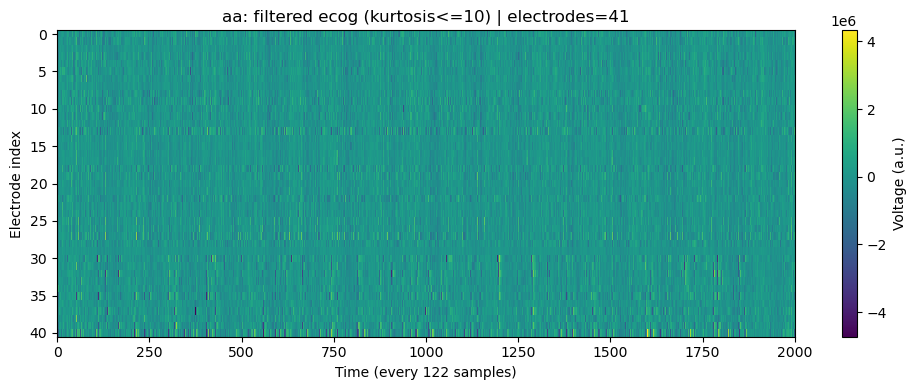

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
subject_files = sorted(out_dir.glob('*_preprocessed.npz'))
if not subject_files:
    raise FileNotFoundError('No *_preprocessed.npz files found in output dir')

first_path = subject_files[0]
pack = np.load(first_path, allow_pickle=True)
pid = str(pack['subject_id'].item())
ecog = pack['ecog']
locs = pack['locs_mni_mm']

step = max(1, ecog.shape[0] // 2000)
ecog_ds = ecog[::step]

plt.figure(figsize=(10, 4))
im = plt.imshow(ecog_ds.T, aspect='auto', cmap='viridis', interpolation='nearest')
plt.colorbar(im, label='Voltage (a.u.)')
plt.xlabel(f'Time (every {step} samples)')
plt.ylabel('Electrode index')
plt.title(f'{pid}: filtered ecog (kurtosis<={kurtosis_thresh}) | electrodes={locs.shape[0]}')
plt.tight_layout()
plt.show()


In [12]:
from pathlib import Path
import numpy as np

out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
subject_files = sorted(out_dir.glob('*_preprocessed.npz'))
if not subject_files:
    raise FileNotFoundError('No *_preprocessed.npz files found in output dir')

path = subject_files[0]
pack = np.load(path, allow_pickle=True)

print(f'File: {path.name}')
print('Keys:', pack.files)
print('subject_id:', pack['subject_id'].item())
print('sample_rate_hz:', int(pack['sample_rate_hz']))
print('locs_mni_mm shape:', pack['locs_mni_mm'].shape)
print('ecog shape:', pack['ecog'].shape)


File: aa_preprocessed.npz
Keys: ['subject_id', 'sample_rate_hz', 'locs_mni_mm', 'ecog']
subject_id: aa
sample_rate_hz: 1000
locs_mni_mm shape: (41, 3)
ecog shape: (244200, 41)


# Optional: combine all per-subject `*_preprocessed.npz` files into one object array

In [13]:
# Run after per-subject files exist
from pathlib import Path
import numpy as np

out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
records = []

for sub_path in sorted(out_dir.glob('*_preprocessed.npz')):
    pack = np.load(sub_path, allow_pickle=True)
    records.append({
        'patient_id': str(pack['subject_id'].item()),
        'sample_rate_hz': int(pack['sample_rate_hz']),
        'locs_mni_mm': pack['locs_mni_mm'],
        'ecog': pack['ecog'],
    })

combined_path = out_dir / 'all_locs_mni_and_ecog_preprocessed.npy'
np.save(combined_path, np.array(records, dtype=object))
print(f'Combined {len(records)} patients to {combined_path}')


Combined 13 patients to /Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed/all_locs_mni_and_ecog_preprocessed.npy


In [14]:
import numpy as np

path = "/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed/all_locs_mni_and_ecog_preprocessed.npy"
all_locs = np.load(path, allow_pickle=True)

print(all_locs.shape)
print(all_locs[0].keys())  # patient_id, sample_rate_hz, locs_mni_mm, ecog


(13,)
dict_keys(['patient_id', 'sample_rate_hz', 'locs_mni_mm', 'ecog'])


# Convert each per-subject preprocessed file to SuperEEG `file_io` input format

In [15]:
from pathlib import Path
import numpy as np

preprocessed_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
npz_out_dir = Path('/Users/rustin/Documents/Big Data 567/Faces_Basic_npz_for_supereeg')
npz_out_dir.mkdir(parents=True, exist_ok=True)

for sub_path in sorted(preprocessed_dir.glob('*_preprocessed.npz')):
    pack = np.load(sub_path, allow_pickle=True)

    pid = str(pack['subject_id'].item())
    Y = pack['ecog']                                   # (time, channels)
    R = pack['locs_mni_mm']                            # (channels, 3) MNI mm
    samplerate   = np.array([int(pack['sample_rate_hz'])])  # 1-D, one value per session
    fname_labels = np.array([pid])                     # one session label

    out_path = npz_out_dir / f'{pid}.npz'
    np.savez(out_path, Y=Y, R=R, samplerate=samplerate, fname_labels=fname_labels)
    print(f'[{pid}] Y={Y.shape} R={R.shape} samplerate={samplerate} -> {out_path.name}')

print('Done.')


[aa] Y=(244200, 41) R=(41, 3) samplerate=[1000] -> aa.npz
[ap] Y=(241200, 40) R=(40, 3) samplerate=[1000] -> ap.npz
[ca] Y=(244200, 49) R=(49, 3) samplerate=[1000] -> ca.npz
[de] Y=(244200, 31) R=(31, 3) samplerate=[1000] -> de.npz
[fp] Y=(244200, 11) R=(11, 3) samplerate=[1000] -> fp.npz
[ha] Y=(242200, 39) R=(39, 3) samplerate=[1000] -> ha.npz
[ja] Y=(244200, 37) R=(37, 3) samplerate=[1000] -> ja.npz
[jt] Y=(244200, 96) R=(96, 3) samplerate=[1000] -> jt.npz
[mv] Y=(244200, 19) R=(19, 3) samplerate=[1000] -> mv.npz
[rn] Y=(244240, 41) R=(41, 3) samplerate=[1000] -> rn.npz
[rr] Y=(162800, 40) R=(40, 3) samplerate=[1000] -> rr.npz
[wc] Y=(244200, 38) R=(38, 3) samplerate=[1000] -> wc.npz
[zt] Y=(244200, 58) R=(58, 3) samplerate=[1000] -> zt.npz
Done.
